In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

TAREA: Crear una imagen con la textura de un tablero de ajedrez

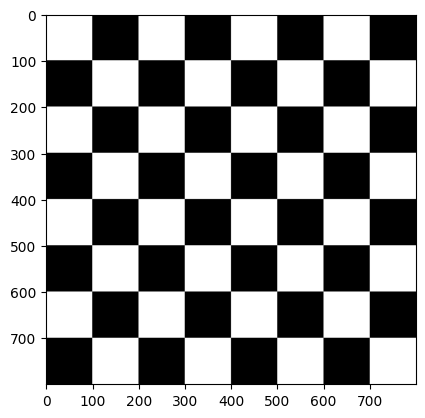

In [2]:
ancho_alto_tablero = 800

segmentos_tablero = 8

ancho_alto_segmento_tablero = 800 // 8

tablero_img = np.zeros((ancho_alto_tablero,ancho_alto_tablero,1), dtype = np.uint8)

for i in range(0, segmentos_tablero):
    for j in range(0, segmentos_tablero):
        if (i % 2 != j % 2):
            continue
        x0 = i * ancho_alto_segmento_tablero
        x1 = x0 + ancho_alto_segmento_tablero
        y0 = j * ancho_alto_segmento_tablero
        y1 = y0 + ancho_alto_segmento_tablero
        tablero_img[y0:y1,x0:x1,0] = 255


plt.imshow(tablero_img, cmap='gray')

plt.show()

TAREA: Hacer uso de las funciones de dibujo de OpenCV para crear una imagen estilo Mondrian

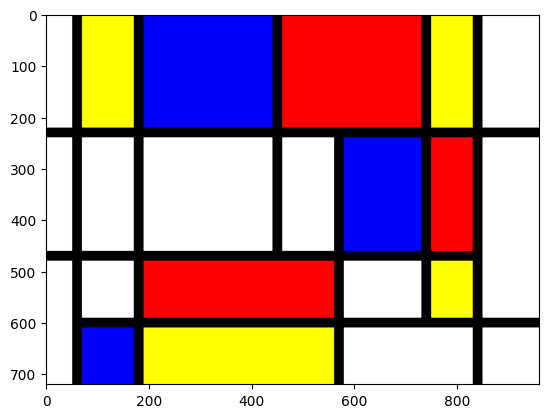

In [ ]:
ancho_img = 960
alto_img = 720

color_img = np.zeros((alto_img,ancho_img,3), dtype = np.uint8)

def pintar_rectangulo(img, color, x0, y0, width, height):
    x1 = x0 + width
    y1 = y0 + height
    cv2.rectangle(img,(x0,y0),(x1,y1),color,-1)

def pintar_blanco():
    color = (255,255,255)
    x0 = 0
    y0 = 0
    width = 50
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    height = alto_img - y0
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    width = 100
    height = 220
    y0 = height + 20
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    height = height // 2
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    width = 250
    height = 220
    y0 = height + 20
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    width = 100
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    y0 = y0 + height + 20
    width = 150
    height = height // 2
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    width = 250
    height = alto_img - y0
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    y0 = 0
    width = ancho_img - x0
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    height = 350
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 20
    height = alto_img - y0
    pintar_rectangulo(color_img, color, x0, y0, width, height)

def pintar_amarillo():
    color = (255,255,0)
    x0 = 70
    y0 = 0
    width = 100
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    y0 = 610
    width = 370
    height = alto_img - y0
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 +width + 190
    y0 = 0
    width = 80
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    y0 = y0 + height + 260
    height = 220 // 2
    pintar_rectangulo(color_img, color, x0, y0, width, height)

def pintar_azul():
    color = (0,0,255)
    x0 = 70
    y0 = 610
    width = 100
    height = alto_img - y0
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    y0 = 0
    width = 250
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 140
    y0 = y0 + height + 20
    width = 150
    pintar_rectangulo(color_img, color, x0, y0, width, height)

def pintar_rojo():
    color = (255,0,0)
    x0 = 190
    y0 = 480
    width = 370
    height = 110
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = 460
    y0 = 0
    width = 270
    height = 220
    pintar_rectangulo(color_img, color, x0, y0, width, height)
    x0 = x0 + width + 20
    y0 = y0 + height + 20
    width = 80
    pintar_rectangulo(color_img, color, x0, y0, width, height)



pintar_blanco()
pintar_amarillo()
pintar_azul()
pintar_rojo()

plt.imshow(color_img) 
plt.show()

TAREA: Destacar tanto el píxel con el color más claro como con el color más oscuro de una imagen

In [214]:
vid = cv2.VideoCapture(0)

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        #Dimensiones imagen de entrada
        h, w, c = frame.shape
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        (minVal, maxVal, minLoc, maxLoc) = cv2.minMaxLoc(gris)
        
        cv2.circle(frame,maxLoc, 4, (0,0,255), -1)
        cv2.circle(frame,minLoc, 4, (255,0,0), -1)
            
        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Hacer una propuesta pop art con la entrada de la cámara web o vídeo

In [217]:
vid = cv2.VideoCapture(0)

def make_dots(frame):
    # set colours (BGR)
    background_colour = [171, 71, 0]
    dots_colour = (51, 250, 250)

    # set the max dots (on the longest side of the image)
    max_dots = 50

    # import the image as greyscale
    original_image = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # extract dimensions
    original_image_height, original_image_width = original_image.shape

    # down size to number of dots
    if original_image_height == max(original_image_height,original_image_width):
        downsized_image = cv2.resize(original_image,(int(original_image_height*(max_dots/original_image_width)),max_dots))
    else:
        downsized_image = cv2.resize(original_image,(max_dots,int(original_image_height*(max_dots/original_image_width))))

    # extract dimensions of new image
    downsized_image_height, downsized_image_width = downsized_image.shape

    # set how big we want our final image to be
    multiplier = 100

    # set the size of our blank canvas
    blank_img_height = downsized_image_height * multiplier
    blank_img_width = downsized_image_width * multiplier

    # set the padding value so the dots start in frame (rather than being off the edge
    padding = int(multiplier/2)

    # create canvas containing just the background colour
    blank_image = np.full(((blank_img_height),(blank_img_width),3), background_colour,dtype=np.uint8)

    # run through each pixel and draw the circle on our blank canvas
    for y in range(0,downsized_image_height):
        for x in range(0,downsized_image_width):
            cv2.circle(blank_image,(((x*multiplier)+padding),((y*multiplier)+padding)), int((0.6 * multiplier) * ((255-downsized_image[y][x])/255)), dots_colour, -1)

    return cv2.resize(blank_image,(original_image_width,original_image_height))

def procesar_imagen(frame,frame_dots,frame_color,frame_hvs,level=0):
    limit = 6
    #Dimensiones imagen de entrada
    h, w, c = frame.shape

    down_frame = cv2.resize(frame,(0,0),cv2.INTER_NEAREST,0.5,0.5)
    down_frame_dots = cv2.resize(frame_dots,(0,0),cv2.INTER_NEAREST,0.5,0.5)
    down_frame_color = cv2.resize(frame_color,(0,0),cv2.INTER_NEAREST,0.5,0.5)
    down_frame_hvs = cv2.resize(frame_hvs,(0,0),cv2.INTER_NEAREST,0.5,0.5)

    frame[0:h//2,w//2:w] = down_frame_dots[0:h//2,0:int(round(w/2,0))]
    frame[h//2:h,0:w//2] = down_frame_color[0:int(round(h/2,0)),0:w//2]
    frame[h//2:h,w//2:w] = down_frame_hvs[0:int(round(h/2,0)),0:int(round(w/2,0))]

    if (level < limit):
        procesar_imagen(down_frame,down_frame_dots,down_frame_color,down_frame_hvs,level+1)
        
    frame[0:h//2,0:w//2] = down_frame[0:h//2,0:w//2]

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        frame_dots = make_dots(frame)
        color_img = np.full((frame.shape[0],frame.shape[1],3), (0,1,0), dtype=np.uint8)
        frame_color = cv2.multiply(255-frame, color_img)
        frame_hvs = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        procesar_imagen(frame,frame_dots,frame_color,frame_hvs)
        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()